========== DATASET SHAPE ==========
(10, 8)

========== DATASET INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Student_ID  10 non-null     int64
 1   Name        10 non-null     str  
 2   Gender      10 non-null     str  
 3   Age         10 non-null     int64
 4   Attendance  10 non-null     int64
 5   Maths       10 non-null     int64
 6   Science     10 non-null     int64
 7   English     10 non-null     int64
dtypes: int64(6), str(2)
memory usage: 772.0 bytes
None

========== SUMMARY STATISTICS ==========
       Student_ID        Age  Attendance      Maths    Science    English
count    10.00000  10.000000   10.000000  10.000000  10.000000  10.000000
mean      5.50000  18.900000   85.200000  81.000000  79.300000  81.200000
std       3.02765   0.875595   11.341174  12.587472  13.038831  11.923832
min       1.00000  18.000000   67.000000  60.0

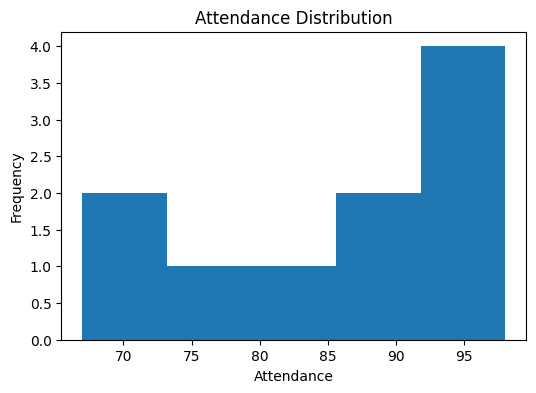

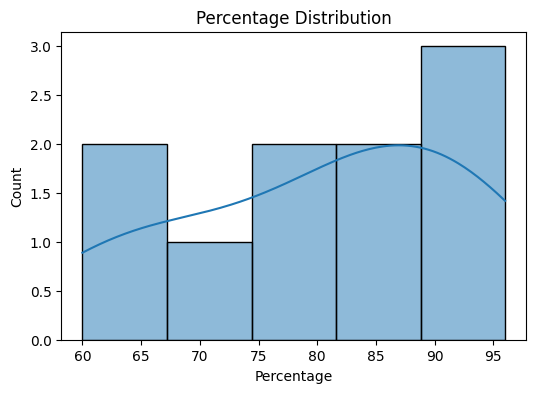

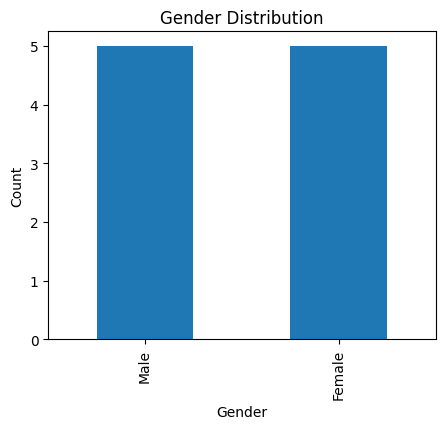

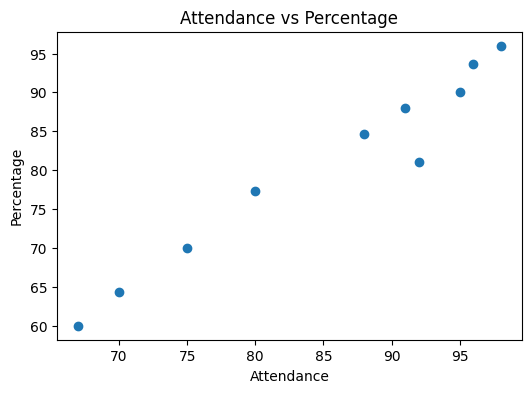

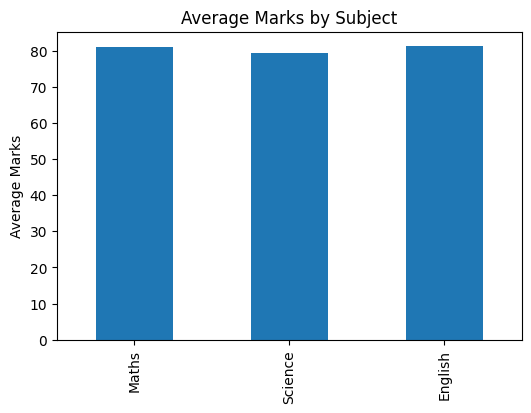

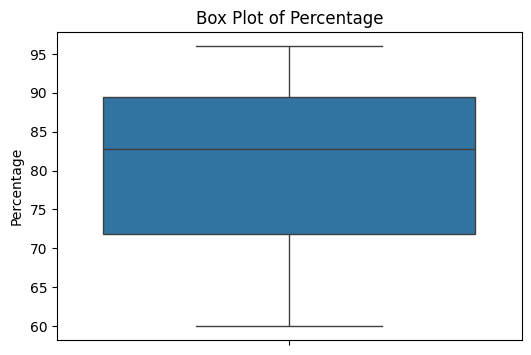

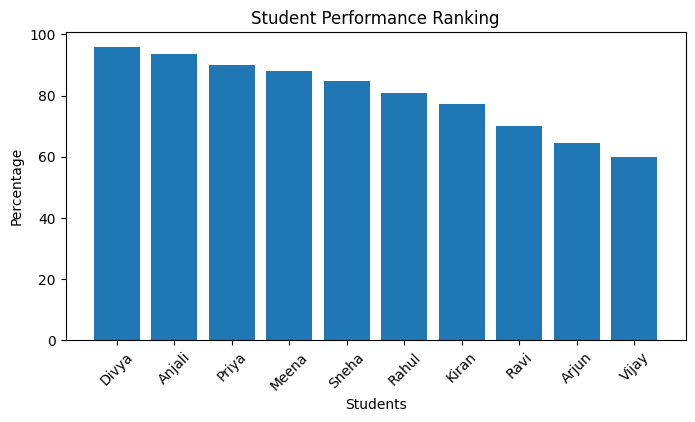

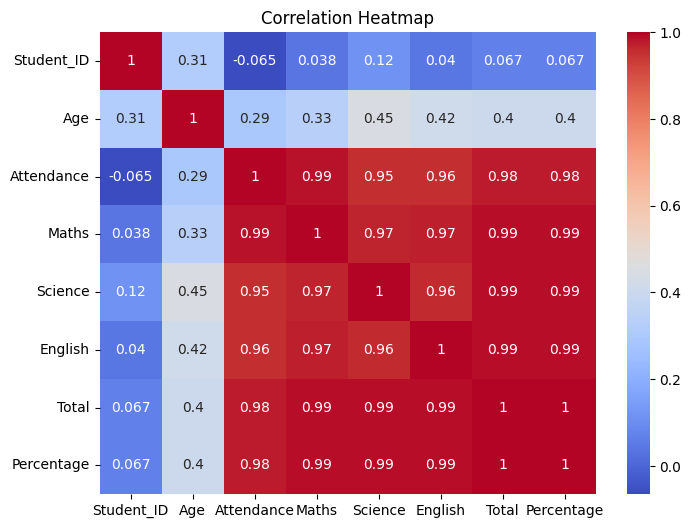


========== INSIGHTS ==========
Average Attendance: 85.2
Average Percentage: 80.5

Top Performing Student:
Name          Divya
Percentage     96.0
Name: 9, dtype: object

Lowest Performing Student:
Name          Vijay
Percentage     60.0
Name: 8, dtype: object


In [2]:

%matplotlib inline

# ==========================================
# STUDENT PERFORMANCE ANALYSIS PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("data_students.csv")

# ==========================================
# STRUCTURAL DIAGNOSIS
# ==========================================

print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== SUMMARY STATISTICS ==========")
print(df.describe())

# ==========================================
# MISSING VALUES CHECK
# ==========================================

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# ==========================================
# DUPLICATE MANAGEMENT
# ==========================================

print("\n========== DUPLICATES BEFORE CLEANING ==========")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\n========== DUPLICATES AFTER CLEANING ==========")
print(df.duplicated().sum())

# ==========================================
# DATA CLEANING
# ==========================================

# Total Marks
df["Total"] = (
    df["Maths"] +
    df["Science"] +
    df["English"]
)

# Percentage
df["Percentage"] = df["Total"] / 3

# Save Clean Dataset
df.to_csv("processed/cleaned_students.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")

# ==========================================
# EDA VISUALIZATIONS
# ==========================================

# 1. Attendance Distribution Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Attendance"], bins=5)
plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

# ==========================================

# 2. Percentage Distribution with KDE
plt.figure(figsize=(6,4))
sns.histplot(df["Percentage"], kde=True)
plt.title("Percentage Distribution")
plt.show()

# ==========================================

# 3. Gender Distribution
plt.figure(figsize=(5,4))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ==========================================

# 4. Attendance vs Percentage
plt.figure(figsize=(6,4))
plt.scatter(df["Attendance"], df["Percentage"])
plt.title("Attendance vs Percentage")
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.show()

# ==========================================

# 5. Subject-wise Average Marks
subjects = ["Maths", "Science", "English"]

plt.figure(figsize=(6,4))
df[subjects].mean().plot(kind="bar")
plt.title("Average Marks by Subject")
plt.ylabel("Average Marks")
plt.show()

# ==========================================

# 6. Box Plot for Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Percentage"])
plt.title("Box Plot of Percentage")
plt.show()

# ==========================================

# 7. Student Performance Ranking
top_students = df.sort_values(
    "Percentage",
    ascending=False
)

plt.figure(figsize=(8,4))
plt.bar(
    top_students["Name"],
    top_students["Percentage"]
)

plt.title("Student Performance Ranking")
plt.xlabel("Students")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

# ==========================================

# 8. Correlation Heatmap
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# INSIGHTS
# ==========================================

print("\n========== INSIGHTS ==========")

print(
    "Average Attendance:",
    round(df["Attendance"].mean(), 2)
)

print(
    "Average Percentage:",
    round(df["Percentage"].mean(), 2)
)

print("\nTop Performing Student:")
print(
    df.loc[
        df["Percentage"].idxmax(),
        ["Name", "Percentage"]
    ]
)

print("\nLowest Performing Student:")
print(
    df.loc[
        df["Percentage"].idxmin(),
        ["Name", "Percentage"]
    ]
)